#### seq2seq 모델
- 각각 RNN으로 이루어져있는 Encoder, Decoder로 구성
- seq2seq 모델의 성능을 개선
    - 입력 시퀀스(출발어)를 반전시켜 Encoder에 넣는 기법
    -Decoder에서 Encoder가 전달해주는 은닉 상태(ℎ)를 Decoder 내의 모든 RNN, Affine 계층도 직접적으로 활용할 수 있도록 Peeky Decoder로 변환해주는 기법
    - 학습 속도 향상/정확도의 향상
- 하이퍼파라미터에 매우 민감하다는 단점

#### 어텐션(Attention) 기법
- seq2seq 모델을 '크게' 개선하는 기법으로서 어텐션(Attention) 기법이 등장
- seq2seq 모델이 마치 인간처럼 필요한 정보에만 '주목(Attention)' 하도록 해줌
- seq2seq의 문제점
    - 동일한 Encoder에는 서로 다른 길이의 시퀀스가 입력되어도 Encoder를 통해 나오는 최종 은닉 상태 ℎ는 항상 모두 동일한 길이의 벡터여만 함
    - 엄청나게 긴 길이의 문장을 입력시켜도 Encoder는 정해진 길이의 벡터 ℎ로 어떻게든 압축해서 변환
    - 벡터 ℎ 일부 정보만 담긴다.

- Encoder에 들어가는 입력 시퀀스 길이에 따라 Encoder가 출력하는 길이를 다르게 해준다
    - Encoder 내의 RNN 계층들이 내뱉는 은닉 상태(ℎ)을 모두 이용

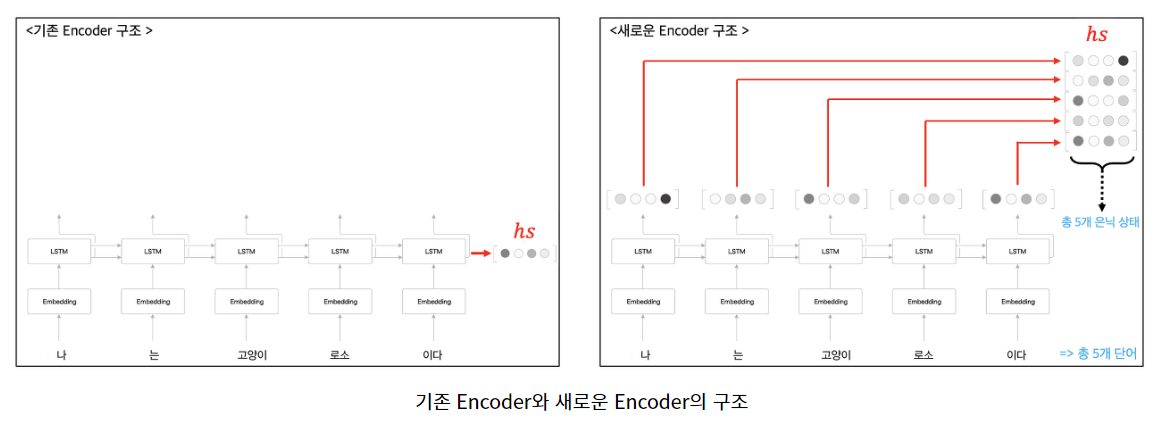

- 디코더 기본 구조

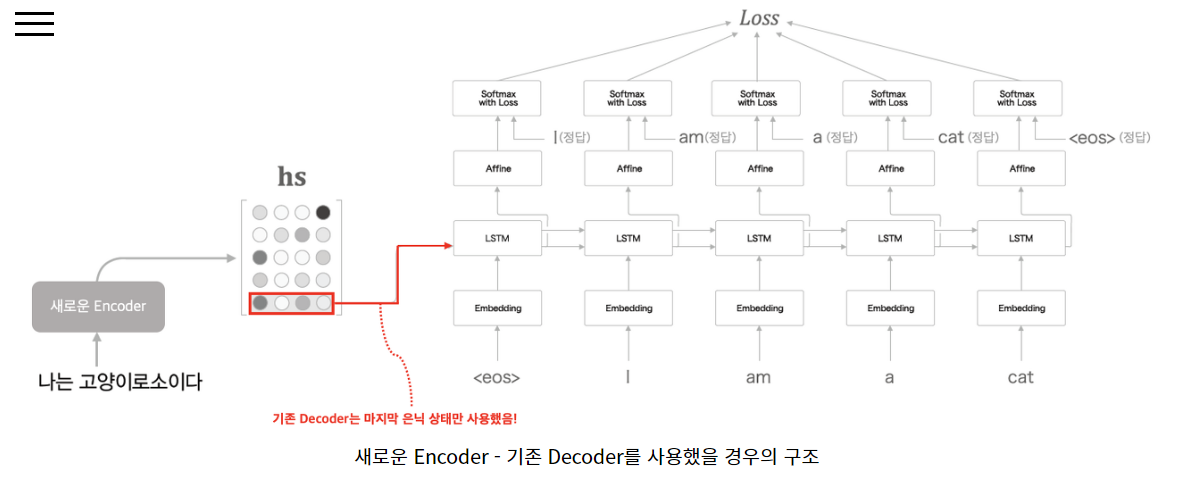

-  A 단어와 대응되는 단어들(B,C,D,E, ... 여러 단어들이 존재할 것임)을 계속 찾아보면서 이 중에 B라는 단어가 A와 가장 관계가 깊고 대응된다고 판단
    - A 단어를 번역하기 위해서 B 단어에 특히 '주목(Attention)'하여야함
- '대응 관계'를 seq2seq 모델에 학습시키자는 것이 바로 어텐션 메커니즘의 핵심
- 이렇게 단어들 간의 대응 관계를 Phrase alignment(얼라인먼트)라고 부른다.
- 어텐션은 이러한 얼라인먼트 작업을 신경망 모델이 알아서 학습해 자동화시킨 기능
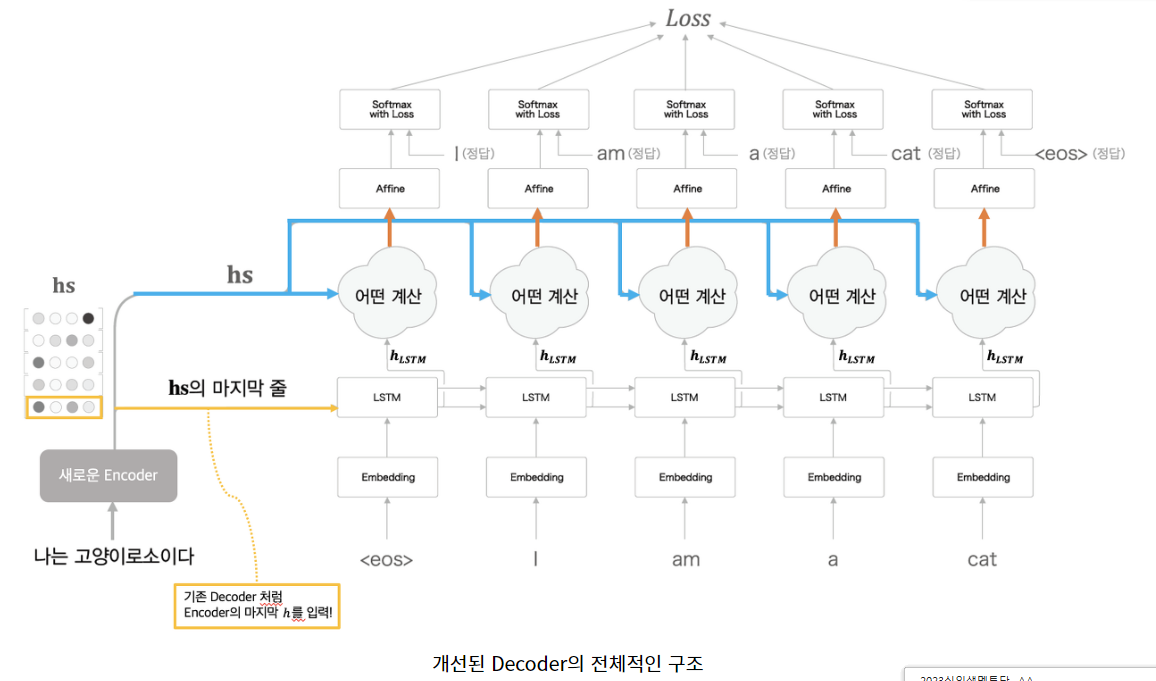

- '어떤 계산' 계층??

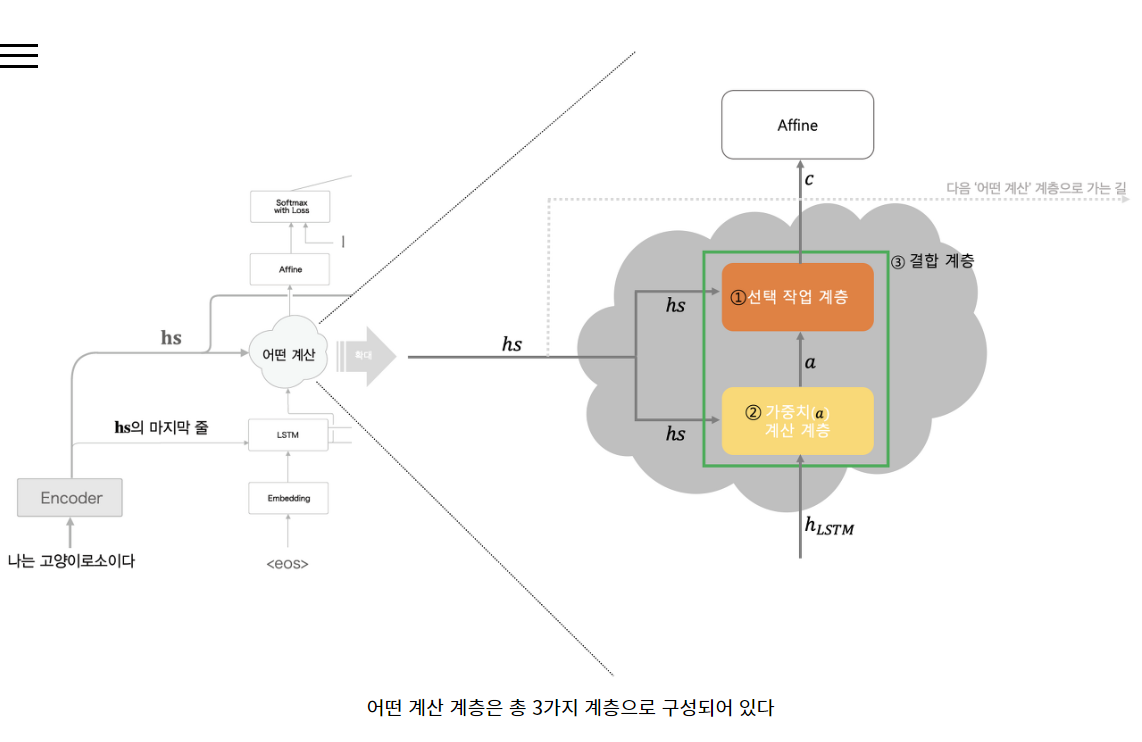

- '어떤 계산' 계층 내부
    - ① 선택 작업 계층
    - ② 가중치(a) 계산 계층 
    - ③ 결합 계층 총 3가지로 구성

① 선택 작업 계층
- 2개의 입력값을 가진다.
    - Encoder가 내뱉은 은닉 상태 벡터를 모두 결합한 hs
    - ②가중치(a) 계산 계층에서 흘러나온 a
- Phrase alignment(얼라인먼트)에 해당
-  Decoder에서 각 시각마다 입력된 단어와 대응 관계에 있는 단어의 정보를 담고 있는 벡터를 hs 중에서 골라낸다
    - hs는 Encoder에 입력된 시퀀스 즉, [나, 는, 고양이, 로소, 이다] 라는 5개의 단어 각각의 정보(5개의 은닉 상태)
    - Decoder에 입력된 'I' 라는 단어 입력시 가장 관련이 깊은 은닉 상태를 hs 중에서 1개를 선택
- 개선된 Decoder를 통해 얼라인먼트 작업 즉, '선택 작업'을 학습(오차역전파를 이용)=> 미분가능한 연산으로 신경망을 구축 필요
- '선택 작업'을 미분가능한 연산으로 변환=>'모든 것을 선택' => 각 은닉 상태마다 가중치를 부여하여 선택
- 선택 작업=>'가중치'라는 것을 활용해 각 은닉 상태마다 가중치를 부여하는 것

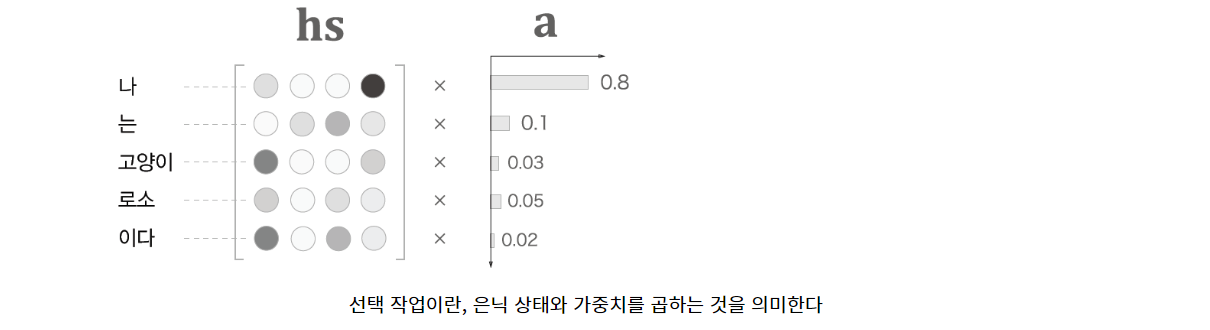

- 가중치 a는 0.0 ~ 1.0 사이의 스칼라 값
- 가중치 a를 모두 더하면 항상 1 이다
- 가중치 a를 각 은닉 상태에 곱해준 후 동일한 위치의 인덱스 값끼리 더한다.(hs와 a를 Weightd sum)
 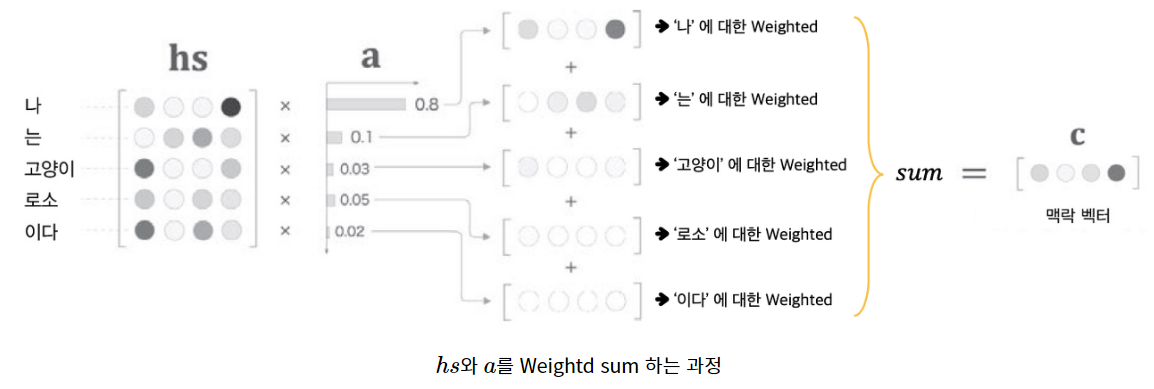
- c에는 '나' 라는 단어에 대한 정보가 많이 포함

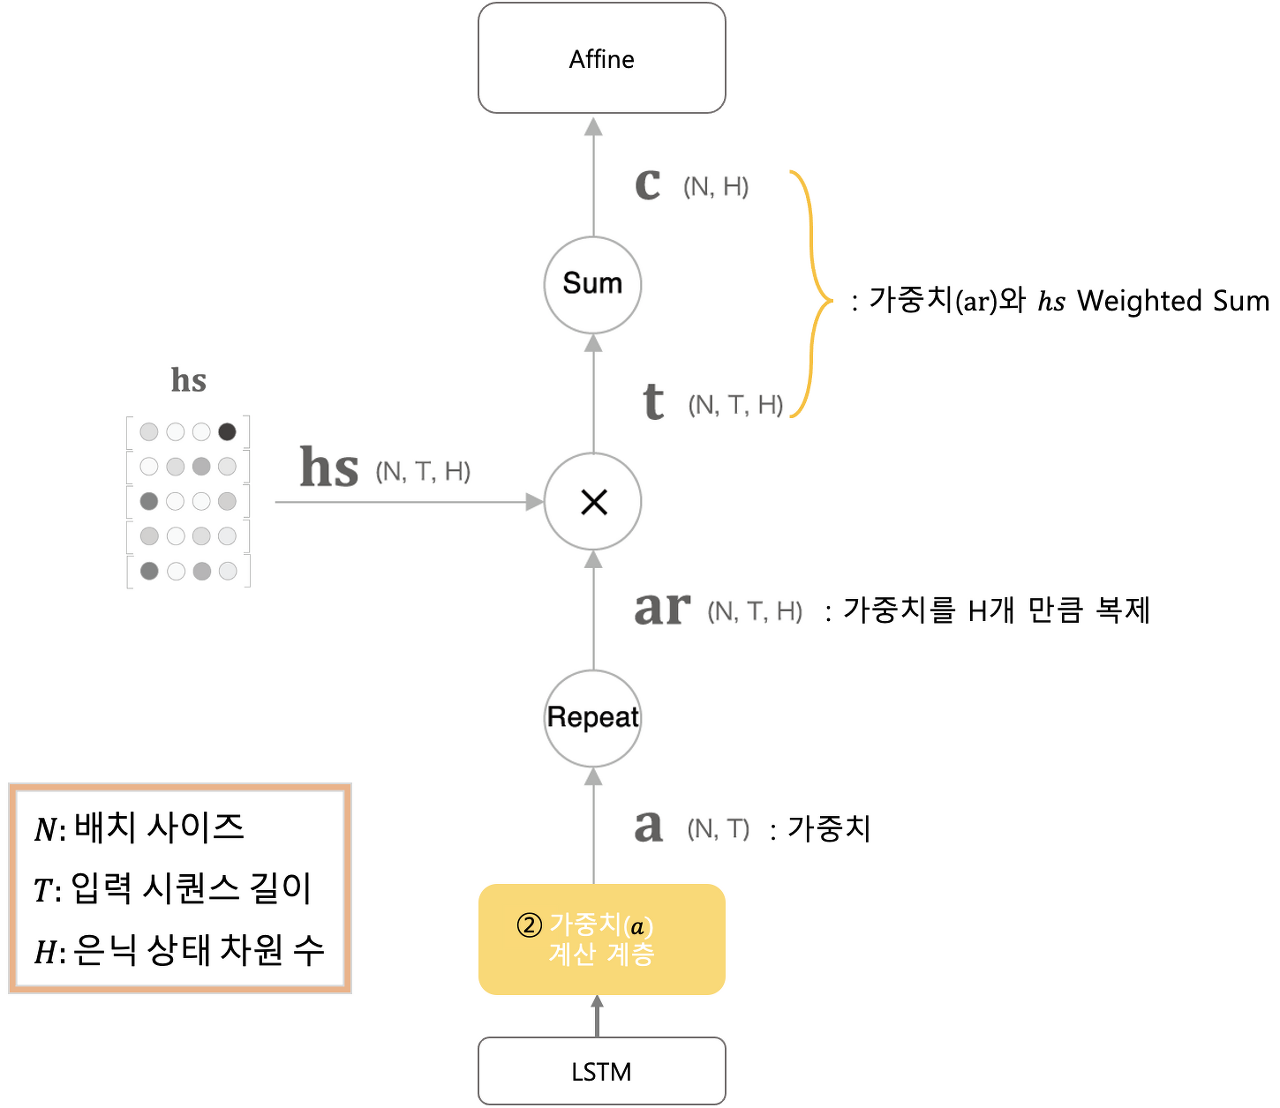

In [ ]:
class WeightedSum:
    """ Encoder의 모든 은닉 상태 hs 와 LSTM 계층에서 흘러나온 가중치 a 간의 Weighted Sum
    """
    
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        
    def forward(self, hs, a):
        """ Weighted Sum 순전파 수행
        
        Args:
            hs: Encoder의 모든 은닉 상태 hs
            a: RNN 계층에서 출력한 은닉상태(현재 shape: (batch_size, 은닉상태 차원 수)
        
        """
        N, T, H = hs.shape   # (bacth_size, 입력시퀀스 길이, 은닉상태 차원 수)
        
        ar = a.reshape(N, T, 1).repeat(H, axis=2)
        t = hs * ar
        c = np.sum(t, axis=1)
        
        self.cache = (hs, ar)
        return c
    
    def backward(self, dc):
        """ Weighted Sum 역전파 수행
        
        Args:
            dc: 순전파 시, Affine 계층으로 전달한 맥락 벡터 c의 기울기 값
        
        """
        hs, ar = self.cache
        N, T, H = hs.shape
        
        dt = dc.reshape(N, 1, H).repeat(T, axis=1)  # sum의 역전파
        dar = dt * hs
        dhs = dt * ar
        
        da = np.sum(dar, axis=2)  # repeat의 역전파
        
        return dhs, da

② 가중치(a) 계산 계층
- Encoder의 은닉 상태 모음인 hs와 LSTM 계층의 출력값인 hLSTM 2개를 입력 받는다.
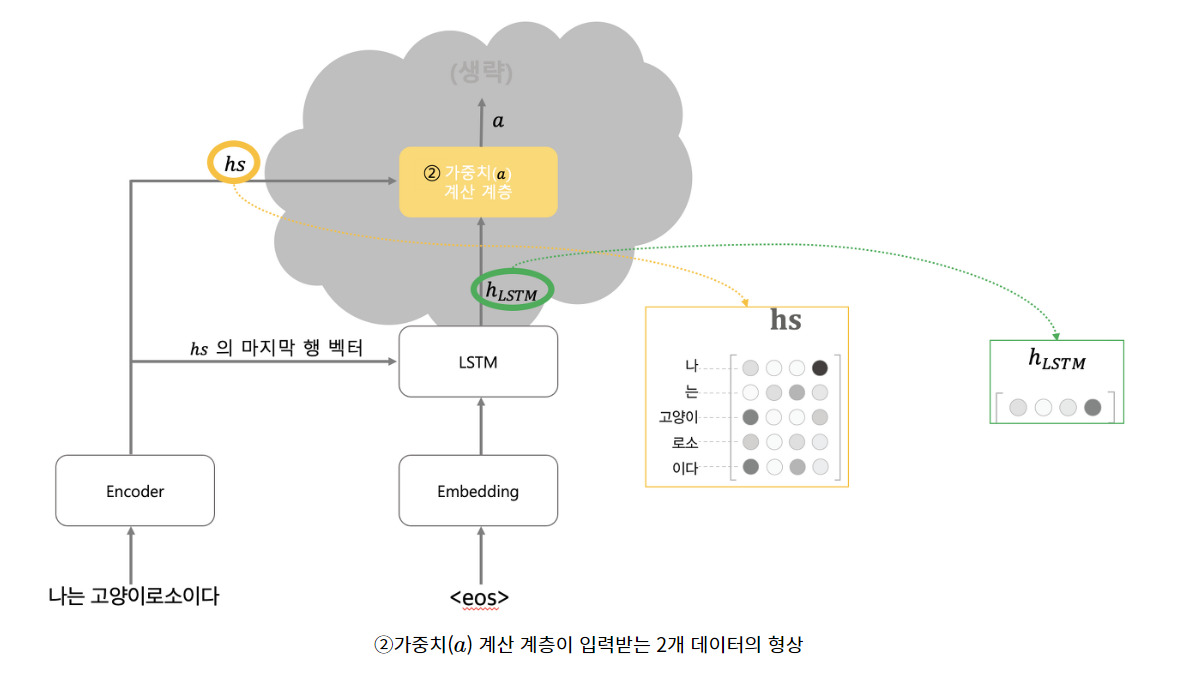

- hLSTM 이 hs에서의 각 은닉 상태와 얼마나 비슷한가(관련이 있는가)를 하나의 수치로 표현하는 가중치(a)를 만들기
- 두 벡터가 가리키는 방향 간의 각도를 구함(유사도)

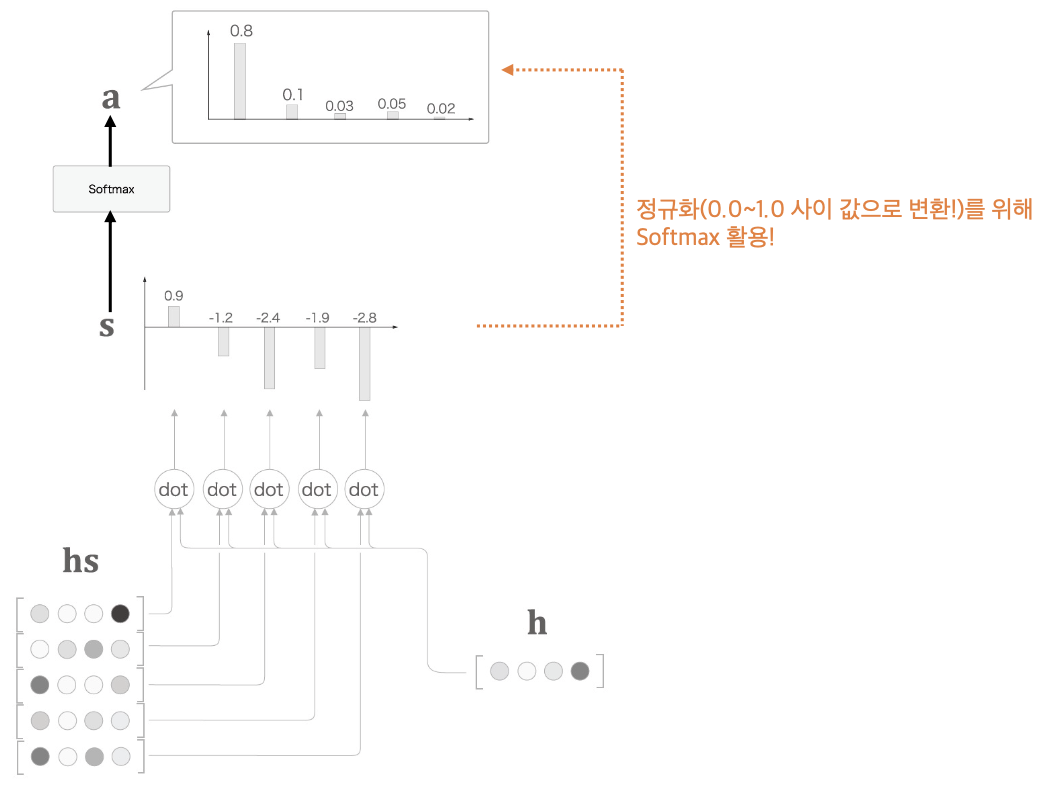

- 가중치 계산 그래프
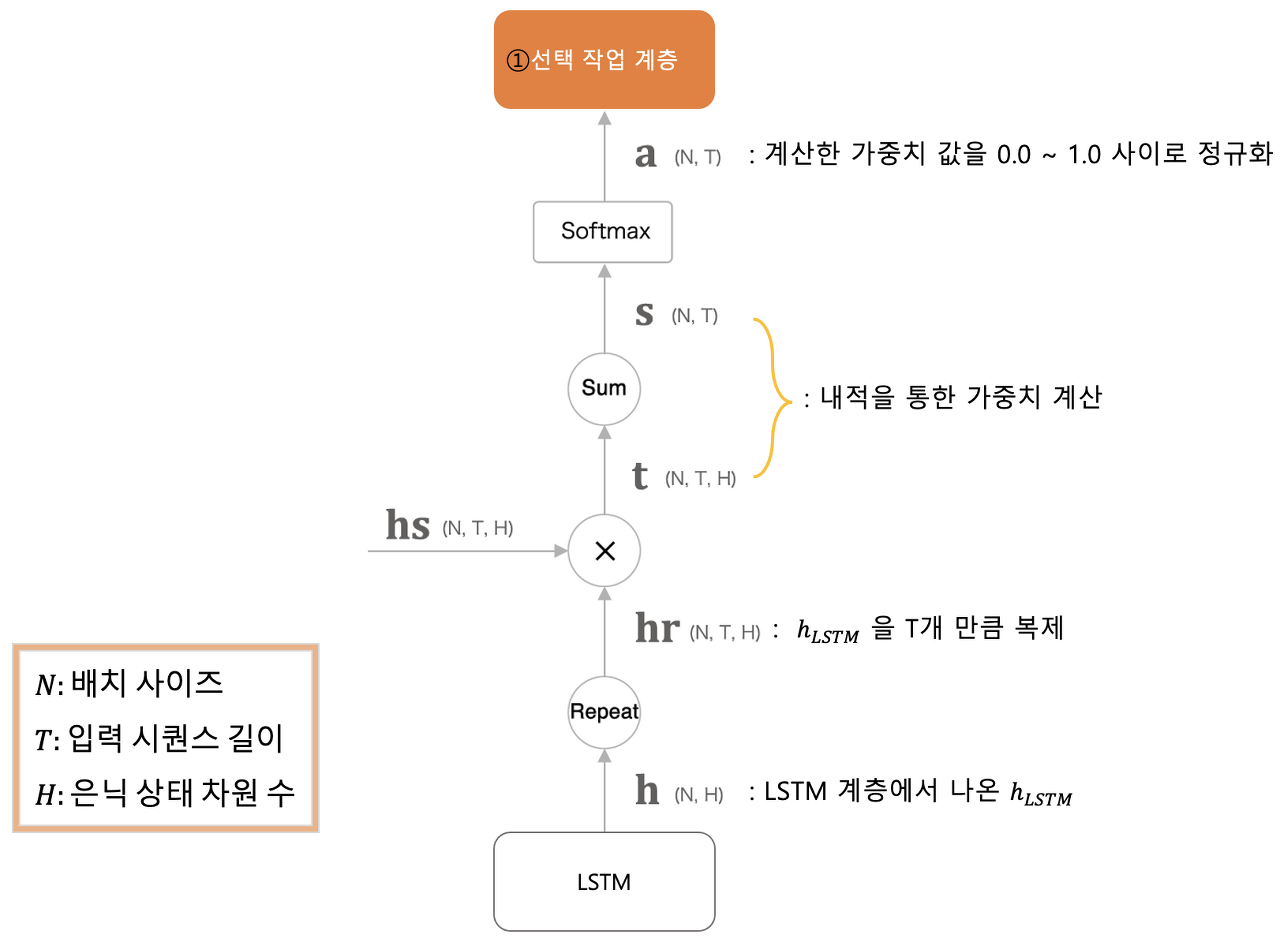


In [ ]:
# (2) 가중치(a) 계산 계층
class AttentionWeight:
    def __init__(self):
        self.params, self.grads = [], []
        self.softmax = softmax()
        self.cache = None
        
        
    def forward(self, hs, h):
        """ 가중치 계산 계층에서의 순전파 수행
        
        Args:
            hs: Encoder의 모든 은닉 상태 hs
            h: RNN 계층에서 출력한 은닉상태(현재 shape: (batch_size, 은닉상태 차원 수)
        """
        N, T, H = hs.shape
        
        hr = h.reshape(N, 1, H).repeat(T, axis=1)  # RNN 계층에서 나온 은닉상태 repeat
        
        # 내적 수행하여 Encoder의 각 은닉 상태와 RNN 계층에서 나온 은닉상태 간의 유사도 각각 계산
        t = hs * hr
        s = np.sum(t, axis=2)
        
        a = self.softmax.forward(s)
        self.cache = (hs, hr)
        return a
    
    def backward(self, da):
        """ 가중치 계산 계층에서의 역전파 수행
        
        Args:
            da: (1) 선택 작업 계층으로 보낸 가중치(a)의 기울기
        
        """
        hs, hr = self.cache
        N, T, H = hs.shape
        
        ds = self.softmax.backward(da)   
        dt = ds.reshape(N, T, 1).repeat(H, axis=2)   # sum의 역전파
        dhr = dt * hs
        dhs = dt * hr
        dh = np.sum(dhr, axis=1)
        
        return dhs, dh

③ 결합 계층
-  ① 선택 작업 계층, ② 가중치(a) 계산 계층을 결합해 하나의 클래스로 구현
- 기존 Decoder의 성격(매 LSTM 계층마다 출력되는 은닉 상태(hLSTM)를 Affine 계층에 입력)을 계승
    - hLSTM을 직접적으로 Affine 계층으로 입력하는 구조를 추가

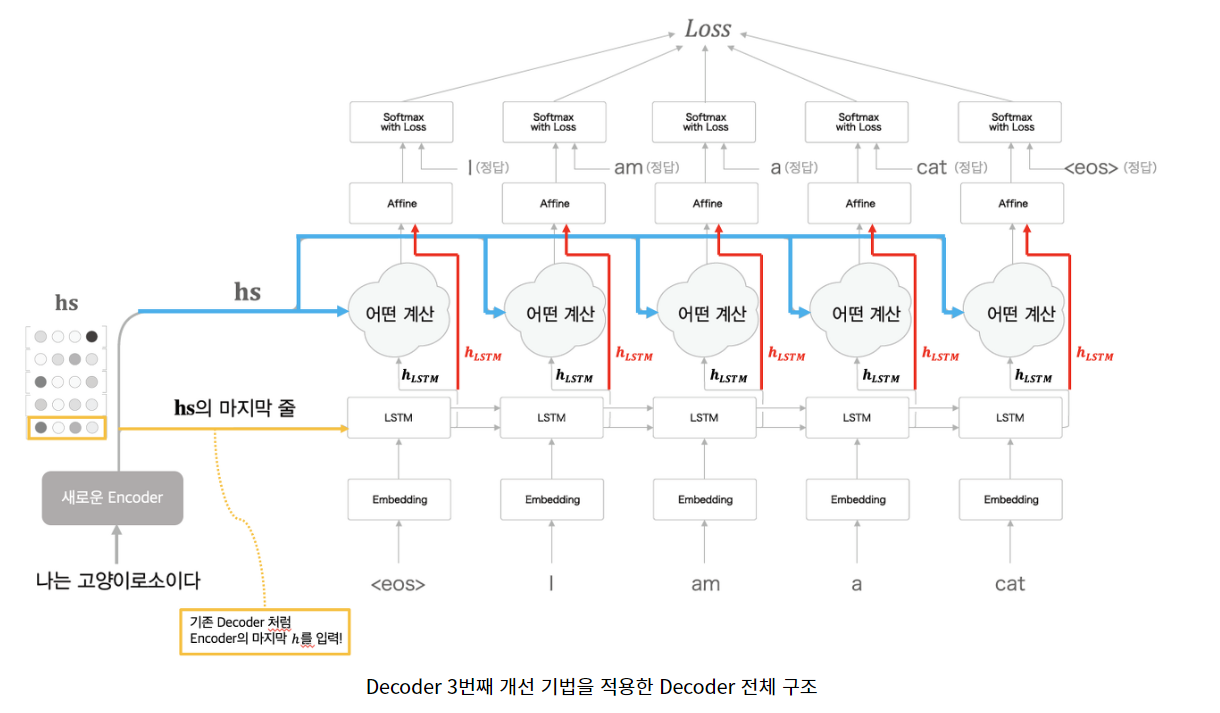


- Affine 계층은 두 개의 데이터를 입력 받는다. 
    - '어떤 계산' 계층(Attention 계층)을 거쳐 나온 맥락 벡터 c와 hLSTM
     -입력받는 두 개를 연결(concatenate)해서 하나의 입력으로 만들어 준 후, Affine 계층에 입력시키는 것

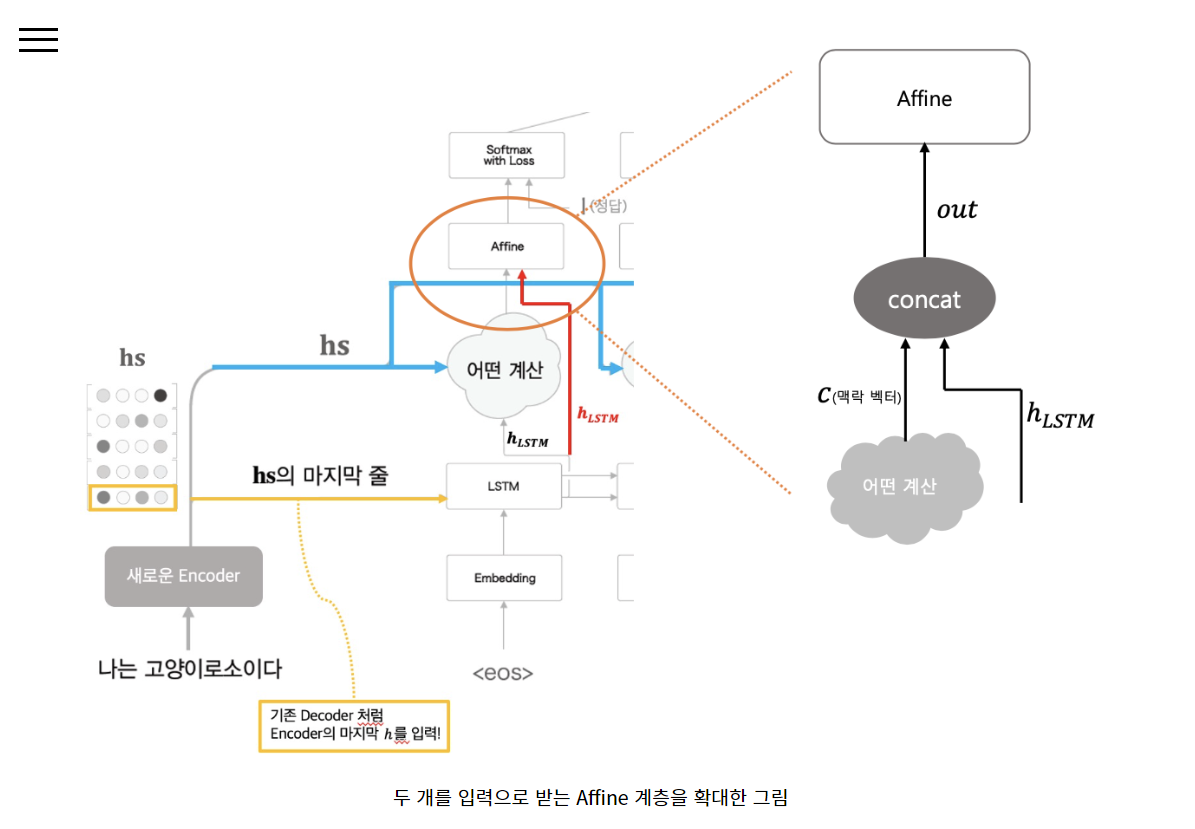


 

- 맥락 벡터를 계산하는 그래프

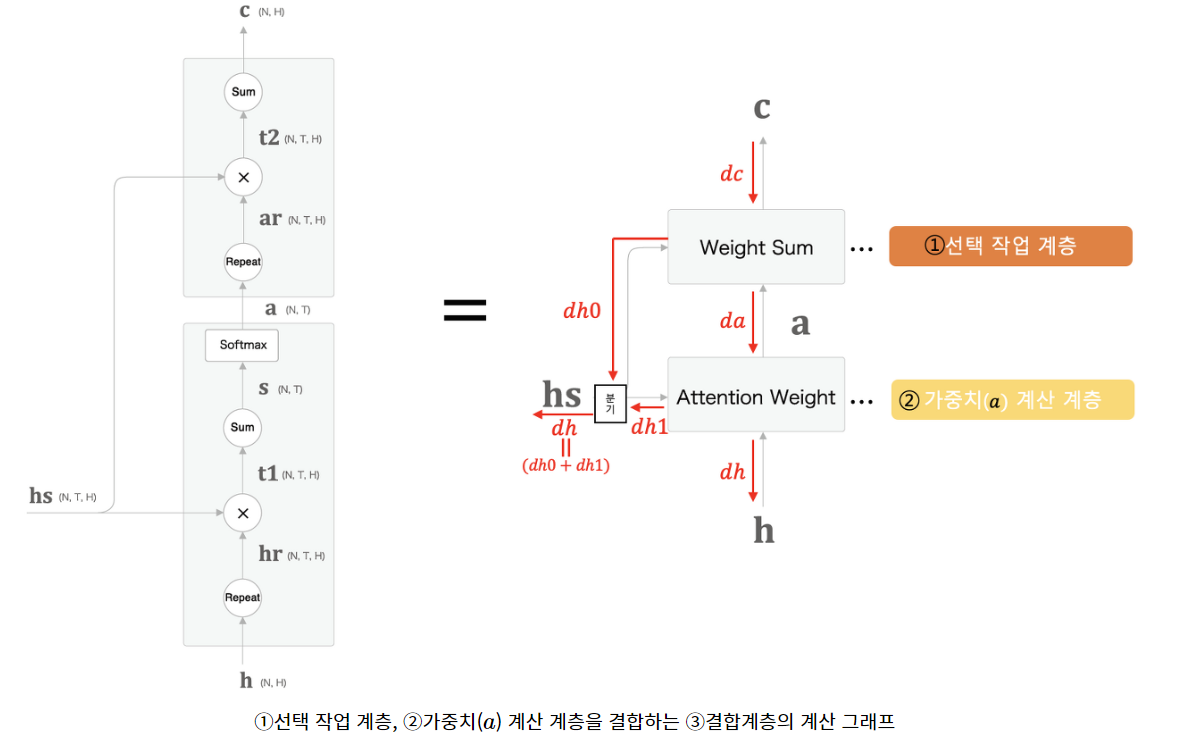

In [ ]:
# (3) 결합계층
class Attention:
    """ (1) 은닉상태, 가중치 간 Weighted sum 계층, (2) 가중치 계산 계층을 결합하는 클래스
    
    """
    def __init__(self):
        self.params, self.grads = [], []
        self.attention_weight_layer = AttentionWeight()  # (2) 가중치 계산 계층
        self.weight_sum_layer = WeightedSum()            # (1) 은닉상태, 가중치 간 Weigted sum 계층
        self.attention_weight = None
    
    
    def forward(self, hs, h):
        """ (3) 결합 계층의 순전파
        
        Args:
            hs: Encoder의 모든 은닉 상태 hs
            h: RNN 계층에서 출력한 은닉상태(현재 shape: (batch_size, 은닉상태 차원 수)
        
        """
        # (2) 가중치 계산
        a = self.attention_weight_layer.forward(hs, h)
        # (1) Weighted sum 계층
        out = self.weight_sum_layer.forward(hs, a)
        self.attention_weight = a
        return out
    
    
    def backward(self, dout):
        """(3) 결합 계층의 역전파
        
        Args:
            dout: Affine 계층으로부터 흘러들어오고 있는 국소적인 미분값
        
        """
        # 순전파 시, hs가 분기(repeat)되어 (1),(2) 계층으로 흘러들어갔으므로 역전파 시 sum!
        dhs0, da = self.weight_sum_layer.backward(dout)
        dhs1, dh = self.attention_weight_layer.backward(da)
        dhs = dhs0 + dhs1
        
        return dhs, dh

- '기존 Decoder의 성격을 계승'은 Attention 메커니즘을 활용해 개선한 seq2seq 모델 전체 구조를 구현할 때 추가
<br><br>
- Encoder에서 한 부분을 개선하고, Decoder 에서는 3가지 부분을 개선함으로써 기계가 인간처럼 필요한 곳에만 '주목'하는 메커니즘을 만들 수 있다.

- 양뱡향 설계(BiLSTM)
    - Encoder의 입력 시퀀스에 해당하는 LSTM만 양방향으로 설계

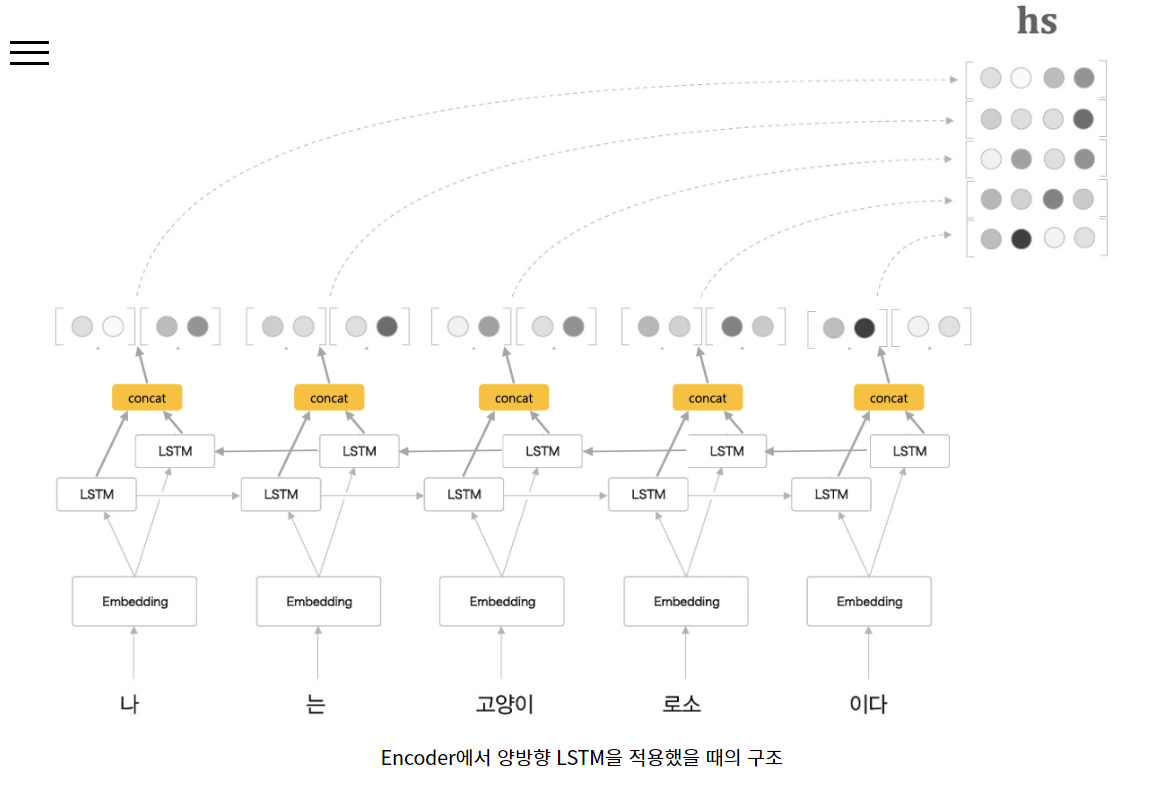 

In [ ]:
# 양방향 LSTM으로 구성된 Time BiLSTM
from common.time_layers import TimeLSTM

class TimeBiLSTM:
    """ 양방향 LSTM을 입력 시퀀스 길이(T)개 한번에 처리하는 클래스
    
    Args:
        Wx1, Wh1, b1: 순전파(왼->오) 방향의 LSTM에 들어갈 파라미터
        Wx2, Wh2, b2: 역전파(오->왼) 방향의 LSTM에 들어갈 파라미터
    """
    def __init__(self, Wx1, Wh1, b1,
                Wx2, Wh2, b2, stateful=False):
        self.forward_lstm = TimeLSTM(Wx1, Wh1, b1, stateful)     # 순전파 방향(왼->오)의 LSTM
        self.backward_lstm = TimeBiLSTM(Wx2. Wh2, b2, stateful)  # 역전파 방향(오->왼)의 LSTM
        
        # 파라미터, 기울기 취합
        self.params = self.forward_lstm.params + self.backward_lstm.params
        self.grads = self.forward_lstm.grads + self.backward_lstm.grads
        
    
    def forward(self, xs):
        """ 양방향 LSTM 순전파
        
        Args:
            xs: 입력 시퀀스 전체
        
        """
        o1 = self.forward_lstm.forward(xs)
        o2 = self.backward_lstm.forward(xs[:, ::-1])
        o2 = o2[:, ::-1]  # 다시 뒤집어야 함!
        
        # concat 노드
        out = np.concatenate((o1, o2), axis=2)
        return out
    
    
    def backward(self, dhs):
        """ 양방향 LSTM 역전파
        
        Args;
            dhs: Encoder가 내뱉은 모든 은닉상태 모음의 기울기
        
        """
        H = dhs.shape[2] // 2  # 은닉상태 차원 수를 2로 나누기(하나는 순전파 방향의 LSTM, 하나는 역전파 방향의 LSTM)
        do1 = dhs[:, :, :H]
        do2 = dhs[:, :, H:]
        
        # 순전파 방향의 LSTM 역전파
        dxs1 = self.forward_lstm.backward(do1)
        # 역전파 방향의 LSTM 역전파
        do2 = do2[:, ::-1]  # 뒤집기
        dxs2 = self.backward_lstm.backward(do2)
        dxs2 = dxs2[:, ::-1]
        
        dxs = dxs1 + dxs2
        return dxs